<a href="https://colab.research.google.com/github/mp371366/ML/blob/main/LAB12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zadanie

## Przygotowanie

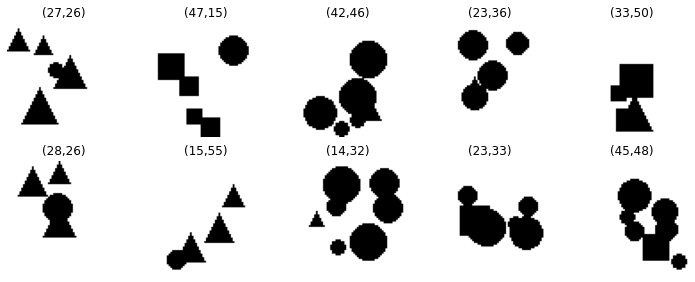

In [ ]:
# ============================================================
# 0. Imports & device
# ============================================================
import torch, random, math, numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# 1. Online dataset: 64×64, target = (cx,cy) ∈ [0,63]²  (float32)
# ============================================================
IMAGE = 64
SHAPES = ("circle", "square", "triangle")

def draw_shape(drawer, shape_type, center_x, center_y, radius):
    if shape_type == "circle":
        drawer.ellipse([center_x - radius, center_y - radius,
                        center_x + radius, center_y + radius], fill="black")
    elif shape_type == "square":
        drawer.rectangle([center_x - radius, center_y - radius,
                          center_x + radius, center_y + radius], fill="black")
    else:  # triangle
        drawer.polygon([
            (center_x, center_y - radius),
            (center_x - radius, center_y + radius),
            (center_x + radius, center_y + radius)
        ], fill="black")

class OddXYDataset(Dataset):
    """
    Generates images on-the-fly:
      * several random shapes of the same type
      * 1 additional shape of a different type
    Returns:
      * image (1×64×64 tensor, float32 normalized to [0,1])
      * label: float tensor [cx, cy] with center of the odd shape
    Arguments:
        num_samples             – total number of samples in the dataset
        same_shape_count_range – tuple (min, max), number of identical shapes
        shape_radius_range      – tuple (min_radius, max_radius) for shape size
    """
    def __init__(self,
                 num_samples,
                 same_shape_count_range=(3, 6),
                 shape_radius_range=(4, 10)):
        self.num_samples = num_samples
        self.same_shape_count_range = same_shape_count_range
        self.radius_min, self.radius_max = shape_radius_range

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        base_shape = random.choice(SHAPES)
        odd_shape = random.choice([s for s in SHAPES if s != base_shape])

        img = Image.new("L", (IMAGE, IMAGE), "white")
        drawer = ImageDraw.Draw(img)

        # draw identical shapes
        for _ in range(random.randint(*self.same_shape_count_range)):
            radius = random.randint(self.radius_min, self.radius_max)
            cx = random.randint(radius, IMAGE - radius - 1)
            cy = random.randint(radius, IMAGE - radius - 1)
            draw_shape(drawer, base_shape, cx, cy, radius)

        # draw the odd shape (with known center)
        radius = random.randint(self.radius_min, self.radius_max)
        cx = random.randint(radius, IMAGE - radius - 1)
        cy = random.randint(radius, IMAGE - radius - 1)
        draw_shape(drawer, odd_shape, cx, cy, radius)

        img_tensor = torch.tensor(np.array(img), dtype=torch.float32).unsqueeze(0) / 255.
        label_tensor = torch.tensor([float(cx), float(cy)], dtype=torch.float32)
        return img_tensor, label_tensor

def show_examples(num_examples=10):
    """
    Displays a grid of image samples from OddXYDataset using a DataLoader with batch_size=1.

    Args:
        num_examples (int): Number of examples to display.
    """
    dataset = OddXYDataset(num_samples=num_examples)
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

    num_columns = 5
    num_rows = math.ceil(num_examples / num_columns)

    fig, axes = plt.subplots(num_rows, num_columns, figsize=(num_columns * 2, num_rows * 2))

    for i, (image, label) in enumerate(dataloader):
        if i >= num_examples:
            break
        image_np = image.squeeze(0).squeeze(0).numpy()  # B=1,C=1,H,W --> H,W
        cx, cy = label.squeeze(0)                       # B=1,2       --> 2
        axes.flat[i].imshow(image_np, cmap="gray")
        axes.flat[i].set_title(f"({cx:.0f},{cy:.0f})")
        axes.flat[i].axis("off")

    for j in range(i + 1, num_rows * num_columns):
        axes.flat[j].axis("off")

    plt.tight_layout()
    plt.show()



show_examples()

## Model

Sieć składa się z 3 głównych modułów.
- CNN Embedding: Filtr konwolucyjny ($20 \times 20$, skok $4$) przekształca obraz $64 \times 64$ w siatkę cech $12 \times 12$ ($144$ obszary), z których każdy jest wektorem $16$-wymiarowym.
- Positional Encoding & Attention: Dodane jest kodowanie sinusoidalne. Następnie $144$ tokeny przechodzą przez mechanizm Self-Attention, co pozwala każdemu fragmentowi obrazu "spojrzeć" na inne i zidentyfikować anomalię (inny kształt).
- Post-processing (Soft Argmax): MLP ocenia każdy ze $144$ tokenów i zamienia to na prawdopodobieństwo (Softmax). Następnie wyliczany jest środek ciężkości (ważona średnia pozycji $x$, $y$).

In [ ]:
import torch
import torch.nn as nn
import math
import torch.optim as optim
from torch.utils.data import DataLoader
# Zakładam, że kod datasetu (OddXYDataset) z poprzedniej wiadomości jest już wczytany

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. Positional Encoding (Krok 2)
# ==========================================
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model=16, max_len=144):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        # Rejestrujemy jako buffer, aby nie było traktowane jako parametr do uczenia
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x: (Batch, 144, 16)
        return x + self.pe

# ==========================================
# 2. Blok Attention z eksportem macierzy (Krok 3)
# ==========================================
class AttentionBlock(nn.Module):
    def __init__(self, d_model=16, num_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)

        # Opcjonalny, lekki FeedForward po atencji (dobra praktyka w Transformerach)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # need_weights=True jest kluczowe dla zadania domowego!
        attn_out, attn_weights = self.attn(x, x, x, need_weights=True)
        x = self.norm1(x + attn_out)
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)
        return x, attn_weights

# ==========================================
# 3. Pełny Model (Kroki 0, 1, 4, 5)
# ==========================================
class OneHeadedOddShapeFinder(nn.Module):
    def __init__(self):
        super().__init__()

        # KROK 1: Embedding obrazu
        # 64x64 -> 16 kanałów, 12x12 pikseli
        self.cnn_embedding = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=20, stride=4, padding=0),
            nn.ReLU()
        )

        # KROK 2: Positional Encoding
        self.pos_encoder = SinusoidalPositionalEncoding(d_model=16, max_len=144)

        # KROK 3: Attention (używam 2 bloków dla lepszej ekspresywności)
        self.attn_blocks = nn.ModuleList([AttentionBlock(d_model=16, num_heads=4) for _ in range(2)])

        # KROK 4: Post-Processing (Token-wise Classifier)
        self.classifier = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        # Przygotowanie siatki współrzędnych dla KROKU 5 (Soft argmax)
        centers_1d = torch.arange(12, dtype=torch.float32) * 4.0 + 9.5
        cy, cx = torch.meshgrid(centers_1d, centers_1d, indexing='ij')
        self.register_buffer('grid_x', cx.flatten()) # Kształt: (144,)
        self.register_buffer('grid_y', cy.flatten()) # Kształt: (144,)

    def forward(self, x):
        # x: (Batch, 1, 64, 64)

        # --- Krok 1: Wyciąganie cech ---
        x = self.cnn_embedding(x)               # (Batch, 16, 12, 12)
        x = x.flatten(2).transpose(1, 2)        # (Batch, 144, 16) - traktujemy jako sekwencję 144 tokenów

        # --- Krok 2: Kodowanie pozycji ---
        x = self.pos_encoder(x)                 # (Batch, 144, 16)

        # --- Krok 3: Attention ---
        all_attn_weights = []
        for block in self.attn_blocks:
            x, attn_weights = block(x)
            all_attn_weights.append(attn_weights)

        # --- Krok 4: Klasyfikator i rozkład prawdopodobieństwa ---
        logits = self.classifier(x).squeeze(-1) # (Batch, 144)
        probs = torch.softmax(logits, dim=1)    # (Batch, 144)

        # --- Krok 5: Final Prediction (Soft Argmax) ---
        pred_x = torch.sum(probs * self.grid_x, dim=1) # Środek ciężkości X
        pred_y = torch.sum(probs * self.grid_y, dim=1) # Środek ciężkości Y

        preds = torch.stack([pred_x, pred_y], dim=1)   # (Batch, 2)

        return preds, probs, all_attn_weights

## Nauka

In [ ]:
# Ustawienie seeda dla powtarzalności
SEED = 424242
torch.manual_seed(SEED)

EPOCHS = 200
SAMPLES_PER_EPOCH = 25000
BATCH_SIZE = 128

model = OneHeadedOddShapeFinder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

# Adaptive Learning Rate - zmniejsza LR, gdy RMSE przestanie spadać
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4, verbose=True)

print("Rozpoczynam trening (cel: RMSE < 5.0)...")

history_rmse = []

for epoch in range(EPOCHS):
    model.train()

    # Tworzymy nowy dataset na każdą epokę - w końcu to model "online"
    dataset = OddXYDataset(num_samples=SAMPLES_PER_EPOCH)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    total_squared_error = 0.0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        preds, probs, attn_weights = model(images)
        loss = criterion(preds, labels)
        loss.backward()
        optimizer.step()

        # Mnożymy przez rozmiar batcha, aby poprawnie wyciągnąć średnią
        total_squared_error += loss.item() * images.size(0)

    # Wyliczamy RMSE dla całej epoki
    epoch_rmse = math.sqrt(total_squared_error / SAMPLES_PER_EPOCH)
    history_rmse.append(epoch_rmse)
    print(f"Epoka {epoch+1:02d}/{EPOCHS} | Train RMSE: {epoch_rmse:.4f} px")

    if epoch_rmse < 5.0:
        print(f"Cel osiągnięty! RMSE < 5.0 px w epoce {epoch+1}.")
        break

    # Przekazujemy metrykę do schedulera
    scheduler.step(epoch_rmse)

Rozpoczynam trening (cel: RMSE < 5.0)...
Epoka 01/200 | Train RMSE: 13.3960 px
Epoka 02/200 | Train RMSE: 13.1172 px
Epoka 03/200 | Train RMSE: 12.1185 px
Epoka 04/200 | Train RMSE: 10.6545 px
Epoka 05/200 | Train RMSE: 9.9490 px
Epoka 06/200 | Train RMSE: 9.6690 px
Epoka 07/200 | Train RMSE: 9.6158 px
Epoka 08/200 | Train RMSE: 9.4466 px
Epoka 09/200 | Train RMSE: 9.1645 px
Epoka 10/200 | Train RMSE: 8.5578 px
Epoka 11/200 | Train RMSE: 8.4031 px
Epoka 12/200 | Train RMSE: 8.1471 px
Epoka 13/200 | Train RMSE: 7.8834 px
Epoka 14/200 | Train RMSE: 7.8091 px
Epoka 15/200 | Train RMSE: 7.4995 px
Epoka 16/200 | Train RMSE: 7.4015 px
Epoka 17/200 | Train RMSE: 7.3853 px
Epoka 18/200 | Train RMSE: 7.0669 px
Epoka 19/200 | Train RMSE: 7.0813 px
Epoka 20/200 | Train RMSE: 6.9000 px
Epoka 21/200 | Train RMSE: 6.7833 px
Epoka 22/200 | Train RMSE: 6.7633 px
Epoka 23/200 | Train RMSE: 6.8169 px
Epoka 24/200 | Train RMSE: 6.4996 px
Epoka 25/200 | Train RMSE: 6.5530 px
Epoka 26/200 | Train RMSE: 6.6

## Krzywa uczenia

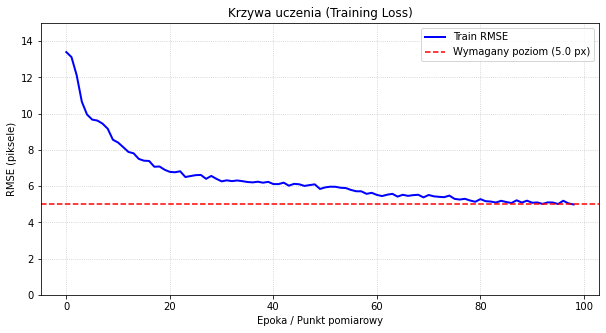

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history_rmse, label='Train RMSE', color='blue', linewidth=2)
plt.axhline(y=5.0, color='red', linestyle='--', label='Wymagany poziom (5.0 px)')

plt.title('Krzywa uczenia (Training Loss)')
plt.xlabel('Epoka / Punkt pomiarowy')
plt.ylabel('RMSE (piksele)')
plt.ylim(0, 15)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Atencja

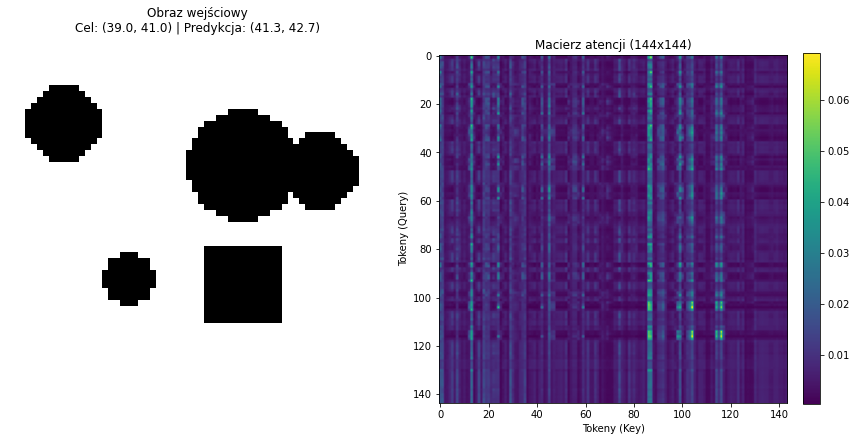

In [ ]:
# Ustawienie modelu w tryb ewaluacji
model.eval()

# Pobranie jednego batcha danych
test_dataset = OddXYDataset(num_samples=10)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)
imgs, labels = next(iter(test_dataloader))
imgs, labels = imgs.to(device), labels.to(device)

# Przepuszczenie przez model
with torch.no_grad():
    preds, probs, attn_weights = model(imgs)

# Wyciągamy macierz z OSTATNIEGO bloku atencji dla pierwszego obrazka
# attn_weights to lista z każdego bloku, wybieramy [-1], a potem indeks z batcha [0]
attn_matrix = attn_weights[-1][0].cpu().numpy()
image_np = imgs[0].squeeze().cpu().numpy()

# Wizualizacja
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image_np, cmap="gray")
axes[0].set_title(f"Obraz wejściowy\nCel: ({labels[0][0]:.1f}, {labels[0][1]:.1f}) | Predykcja: ({preds[0][0]:.1f}, {preds[0][1]:.1f})")
axes[0].axis('off')

# Macierz ma rozmiar 144x144 (ponieważ mamy 144 tokeny)
im = axes[1].imshow(attn_matrix, cmap="viridis")
axes[1].set_title("Macierz atencji (144x144)")
axes[1].set_xlabel("Tokeny (Key)")
axes[1].set_ylabel("Tokeny (Query)")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### Dyskusja nad atencją

Gdzie skupia się model? Macierz o wymiarach $144 \times 144$ reprezentuje relacje między tokenami. Zauważamy pionowe jaśniejsze linie.Co one oznaczają? Jasna linia przy konkretnym indeksie oznacza, że wszystkie inne tokeny (obszary obrazu) zwracają dużą uwagę na ten jeden konkretny obszar.Czy koreluje to z pozycją ukrytego kształtu? Tak! Model uczy się, że gdy większość tokenów widzi np. "kółko", a jeden z tokenów ma w sobie "trójkąt", cała uwaga sieci zostaje przekierowana na token z trójkątem. To właśnie ten token otrzymuje najwyższe prawdopodobieństwo przed soft-argmaxem.